In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
{0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}


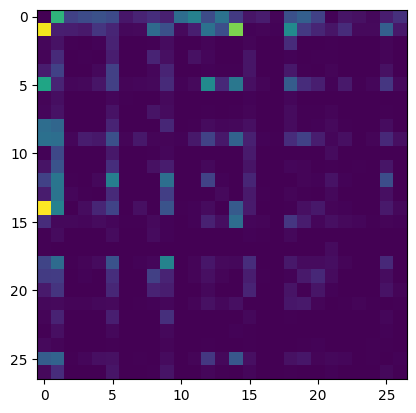

In [3]:
import torch
N = torch.zeros((27, 27), dtype=torch.int32)

chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}
itos = {i:s for s,i in stoi.items()}

print(stoi)
print(itos)

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(N)

In [22]:
P = N.float()
P = P / P.sum(1, keepdim=True)
out = []
ix = 0
while True:
    p = P[ix]
    #print(ix)
    ix = torch.multinomial(p, num_samples=1, replacement=True).item()
    out.append(itos[ix])
    if ix == 0:
        break
print(''.join(out))

mampy.


In [24]:
log_likelihood = 0.0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        log_likelihood += torch.log(P[ix1, ix2])

print(log_likelihood)
nll = -log_likelihood / sum(len(w) + 1 for w in words)
print(nll)

tensor(-559891.7500)
tensor(2.4541)


In [26]:
xs, ys  = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)


xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [ ]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()

In [34]:
W = torch.randn((27,27), requires_grad=True)

for i in range(100):

    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(ys.shape[0]), ys].log().mean()

    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

    print(f'Iteration {i}: loss = {loss:.4f}')

Iteration 0: loss = 3.6085
Iteration 1: loss = 3.2767
Iteration 2: loss = 3.0856
Iteration 3: loss = 2.9644
Iteration 4: loss = 2.8793
Iteration 5: loss = 2.8167
Iteration 6: loss = 2.7699
Iteration 7: loss = 2.7339
Iteration 8: loss = 2.7054
Iteration 9: loss = 2.6821
Iteration 10: loss = 2.6628
Iteration 11: loss = 2.6465
Iteration 12: loss = 2.6325
Iteration 13: loss = 2.6203
Iteration 14: loss = 2.6097
Iteration 15: loss = 2.6002
Iteration 16: loss = 2.5918
Iteration 17: loss = 2.5843
Iteration 18: loss = 2.5776
Iteration 19: loss = 2.5715
Iteration 20: loss = 2.5660
Iteration 21: loss = 2.5609
Iteration 22: loss = 2.5562
Iteration 23: loss = 2.5520
Iteration 24: loss = 2.5480
Iteration 25: loss = 2.5443
Iteration 26: loss = 2.5409
Iteration 27: loss = 2.5378
Iteration 28: loss = 2.5348
Iteration 29: loss = 2.5320
Iteration 30: loss = 2.5294
Iteration 31: loss = 2.5269
Iteration 32: loss = 2.5246
Iteration 33: loss = 2.5224
Iteration 34: loss = 2.5203
Iteration 35: loss = 2.5183
It

In [ ]:
block_size = 3
space_dim = 2
X, Y = [], []

for w in words:
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)



In [62]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [75]:
C = torch.randn((27, space_dim))
emb = C[X]
W1 = torch.randn((block_size*space_dim, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(emb.shape[0], block_size*space_dim) @ W1 + b1)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

for _ in range(100):
    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(emb.shape[0], block_size*space_dim) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])

    for p in params:
        p.grad = None
    loss.backward()

    for p in params:
        p.data += -0.1 * p.grad

    print(loss.item())


14.087892532348633
11.835515975952148
11.624804496765137
11.583590507507324
11.254525184631348
10.32850170135498
8.194097518920898
9.451788902282715
10.832551002502441
8.891568183898926
9.53178596496582
8.798698425292969
9.023703575134277
9.234090805053711
9.647603988647461
9.788317680358887
6.774792194366455
6.3893327713012695
6.541843891143799
7.280149936676025
6.7205119132995605
5.909412860870361
5.771350383758545
7.323897361755371
5.974245071411133
5.361532688140869
5.801698684692383
5.115659236907959
5.043967247009277
5.968835353851318
5.596648693084717
5.629292964935303
4.9791741371154785
4.711066722869873
5.279759883880615
5.074378490447998
4.311890602111816
5.796054363250732
5.263558864593506
5.0237860679626465
5.091956615447998
3.9474422931671143
3.8891050815582275
4.435460090637207
4.950033664703369
3.589594841003418
5.369138717651367
4.492345809936523
4.972450256347656
4.213986873626709
3.554971218109131
4.517017841339111
3.4858853816986084
3.230896234512329
3.30930304527282

In [76]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [78]:
C = torch.randn((27, space_dim))
emb = C[Xtr]
W1 = torch.randn((block_size*space_dim, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(emb.shape[0], block_size*space_dim) @ W1 + b1)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

for _ in range(10000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(emb.shape[0], block_size*space_dim) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in params:
        p.grad = None
    loss.backward()

    for p in params:
        p.data += -0.1 * p.grad

    print(loss.item())


17.265565872192383
15.626709938049316
15.211179733276367
10.774325370788574
10.967296600341797
12.096370697021484
10.345027923583984
10.675824165344238
10.49239444732666
11.738275527954102
9.60952377319336
8.923388481140137
9.43858814239502
8.019357681274414
9.705493927001953
10.916295051574707
8.480972290039062
8.773782730102539
7.0407209396362305
7.266977787017822
7.509336471557617
9.19226360321045
6.250659942626953
6.62183952331543
5.863967418670654
6.5959882736206055
7.247056007385254
7.048559665679932
7.04130744934082
6.7530436515808105
7.32236385345459
5.61503267288208
5.875034332275391
6.530343055725098
6.0070672035217285
4.9273576736450195
5.14327335357666
5.898299694061279
5.267597198486328
6.482226371765137
5.568959712982178
4.765739440917969
5.50938606262207
4.7733540534973145
4.858239650726318
4.51043176651001
5.224428653717041
5.213688373565674
3.8416004180908203
3.5353076457977295
5.2855000495910645
5.1586103439331055
6.7039794921875
6.236354827880859
4.107128143310547
3.

In [79]:
emb = C[Xdev]
h = torch.tanh(emb.view(emb.shape[0], block_size*space_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.8247876167297363
